# Параметрический вариант базового опыта

Требование §4.2 проверяется на независимом наборе сочетаний заразности и
продолжительности болезни. Для каждого сочетания сохраняются траектория и
эпидемиологические показатели.

## Подключение проекта

In [1]:
using DrWatson
@quickactivate "AgentSIRLab"
using DataFrames
include(srcdir("experiment_tools.jl"))

summarize_groups (generic function with 1 method)

## Серия прогонов

In [2]:
settings = [
    (name="мягкий", beta=0.18, period=10, seed=71),
    (name="средний", beta=0.32, period=12, seed=72),
    (name="интенсивный", beta=0.50, period=14, seed=73),
]
all_trajectories = DataFrame()
summary_rows = NamedTuple[]
for p in settings
    _, rows = run_sir(Ns=[700, 700, 700], β_und=fill(p.beta, 3),
        β_det=fill(p.beta / 10, 3), infection_period=p.period,
        detection_time=min(7, p.period), death_rate=0.02,
        reinfection_probability=0.1, Is=[0, 0, 2], seed=p.seed, n_steps=120)
    frame = DataFrame(rows)
    frame.scenario .= p.name
    append!(all_trajectories, frame)
    push!(summary_rows, merge((scenario=p.name, beta=p.beta,
        infection_period=p.period, R0=basic_reproduction_number(p.beta, p.period)),
        epidemic_metrics(frame, 2100)))
end
save_frame(all_trajectories, "sir-run-basic__param", "trajectories.csv")
summary = save_frame(DataFrame(summary_rows), "sir-run-basic__param", "summary.csv")

Row,scenario,beta,infection_period,R0,peak_fraction,peak_day,final_infected,final_recovered,deaths,attack_rate
,String,Float64,Int64,Float64,Float64,Int64,Float64,Float64,Int64,Float64
1,мягкий,0.18,10,1.8,0.00190476,5,0.0,0.00190476,0,0.00190476
2,средний,0.32,12,3.84,0.998538,40,0.994952,0.00428571,317,1.0
3,интенсивный,0.5,14,7.0,1.0,16,1.0,0.0,321,1.0


## Сравнение доли инфицированных

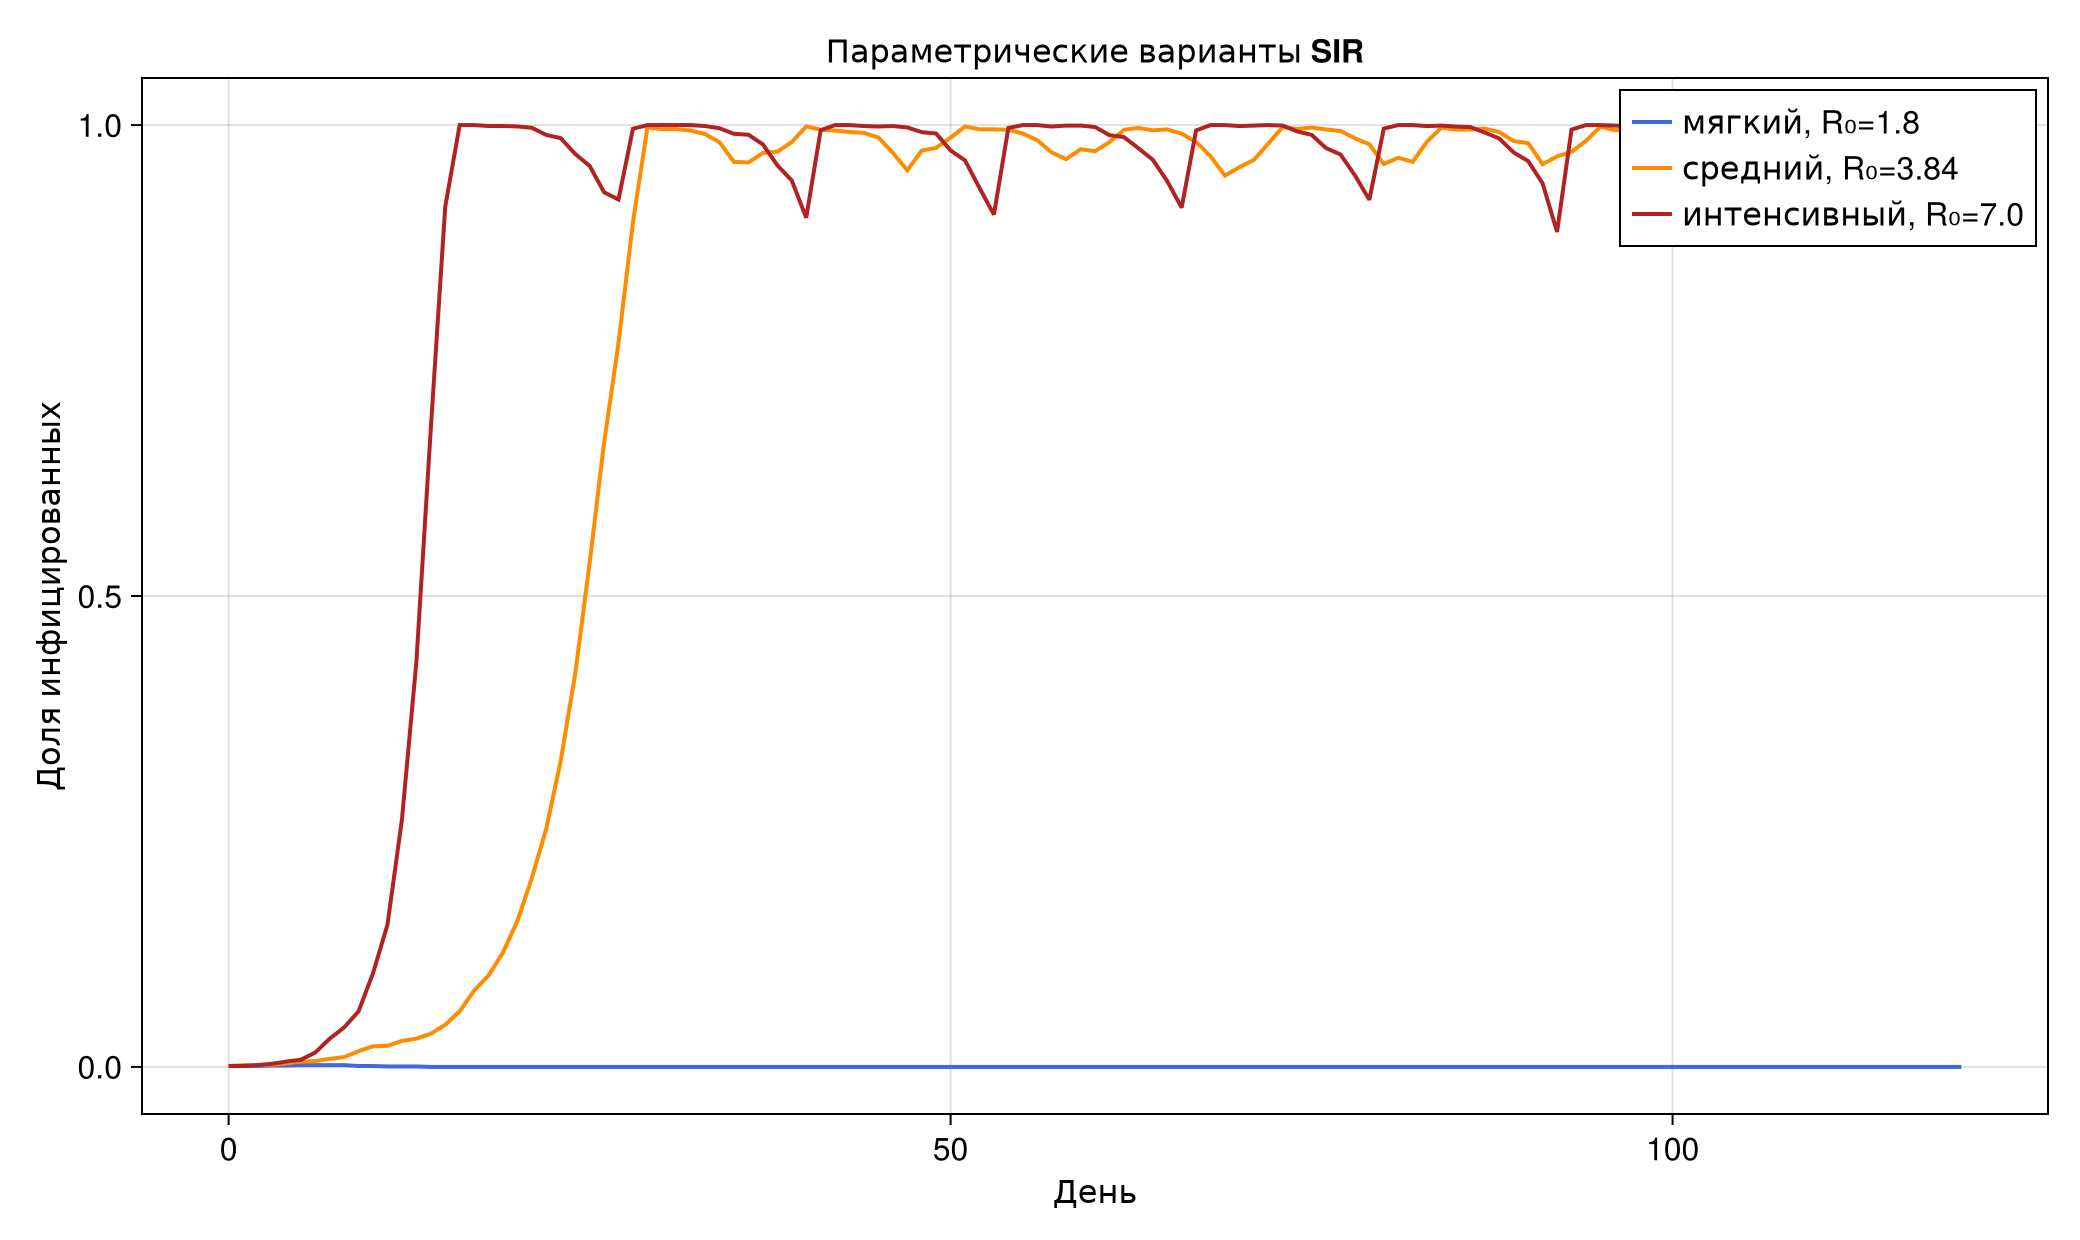

Row,scenario,beta,infection_period,R0,peak_fraction,peak_day,final_infected,final_recovered,deaths,attack_rate
,String,Float64,Int64,Float64,Float64,Int64,Float64,Float64,Int64,Float64
1,мягкий,0.18,10,1.8,0.00190476,5,0.0,0.00190476,0,0.00190476
2,средний,0.32,12,3.84,0.998538,40,0.994952,0.00428571,317,1.0
3,интенсивный,0.5,14,7.0,1.0,16,1.0,0.0,321,1.0


In [3]:
fig = Figure(size=(1040, 620))
ax = Axis(fig[1, 1], title="Параметрические варианты SIR", xlabel="День",
          ylabel="Доля инфицированных")
for (p, colour) in zip(settings, (:royalblue, :darkorange, :firebrick))
    subset = filter(:scenario => ==(p.name), all_trajectories)
    lines!(ax, subset.time, subset.infected_fraction; label="$(p.name), R₀=$(round(p.beta*p.period; digits=2))", color=colour)
end
axislegend(ax; position=:rt)
save_figure(fig, "sir-run-basic__param", "parameter-comparison.png";
            report_name="sir-parameter-comparison.png")
display(fig)
summary